In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [6]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [7]:
import joblib

In [10]:
data = pd.read_csv(r"C:\Users\ACER\Downloads\wearable_health_devices_performance_upto_26june2025.csv")

In [11]:
data.head()

,Test_Date,Device_Name,Brand,Model,Category,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,Water_Resistance_Rating,User_Satisfaction_Rating,GPS_Accuracy_Meters,Connectivity_Features,Health_Sensors_Count,App_Ecosystem_Support,Performance_Score
0,01/06/2025,Fitbit Inspire 4,Fitbit,Inspire 4,Fitness Tracker,141.74,129.9,89.69,93.03,78.91,3ATM,6.5,NaN,"Bluetooth, WiFi",5,Cross-platform,68.4
1,01/06/2025,Apple Watch SE 3,Apple,Watch SE 3,Smartwatch,834.64,26.5,95.92,98.20,79.76,IP68,8.3,4.9,"WiFi, Bluetooth, NFC",8,iOS,60.1
2,01/06/2025,Fitbit Versa 4,Fitbit,Versa 4,Sports Watch,145.34,161.2,92.24,96.81,74.49,IPX8,6.0,1.7,Bluetooth,7,Cross-platform,59.3
3,01/06/2025,Polar Vantage V3,Polar,Vantage V3,Smartwatch,349.53,69.4,96.77,95.56,78.06,IP68,8.0,3.2,"WiFi, Bluetooth, NFC, LTE",12,Cross-platform,61.0
4,01/06/2025,Samsung Galaxy Watch FE,Samsung,Galaxy Watch FE,Smartwatch,502.43,39.7,92.27,98.15,75.23,IPX8,8.3,1.6,"WiFi, Bluetooth, NFC, LTE",14,Android/iOS,61.2


In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2375 entries, 0 to 2374
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Test_Date                        2375 non-null   str    
 1   Device_Name                      2375 non-null   str    
 2   Brand                            2375 non-null   str    
 3   Model                            2375 non-null   str    
 4   Category                         2375 non-null   str    
 5   Price_USD                        2375 non-null   float64
 6   Battery_Life_Hours               2375 non-null   float64
 7   Heart_Rate_Accuracy_Percent      2375 non-null   float64
 8   Step_Count_Accuracy_Percent      2375 non-null   float64
 9   Sleep_Tracking_Accuracy_Percent  2375 non-null   float64
 10  Water_Resistance_Rating          2375 non-null   str    
 11  User_Satisfaction_Rating         2375 non-null   float64
 12  GPS_Accuracy_Meters            

In [13]:
data.describe()

,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,User_Satisfaction_Rating,GPS_Accuracy_Meters,Health_Sensors_Count,Performance_Score
count,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,1743.000000,2375.000000,2375.000000
mean,359.444484,160.584463,93.483907,95.910198,78.837516,7.966484,3.247676,8.912842,64.047621
std,215.671035,234.815896,3.172078,1.665484,4.843714,0.831801,1.022825,3.559990,5.109075
min,30.000000,18.000000,85.010000,93.000000,70.000000,6.000000,1.500000,2.000000,55.100000
25%,211.875000,46.900000,92.140000,94.550000,75.610000,7.400000,2.400000,6.000000,60.400000
50%,334.370000,99.800000,94.070000,95.950000,78.300000,8.000000,3.200000,9.000000,62.200000
75%,487.930000,177.400000,95.925000,96.960000,81.930000,8.500000,4.100000,12.000000,67.700000
max,989.480000,2118.100000,98.000000,99.500000,91.970000,9.500000,5.000000,15.000000,78.300000


In [14]:
data.isnull().sum()

Test_Date                            0
Device_Name                          0
Brand                                0
Model                                0
Category                             0
Price_USD                            0
Battery_Life_Hours                   0
Heart_Rate_Accuracy_Percent          0
Step_Count_Accuracy_Percent          0
Sleep_Tracking_Accuracy_Percent      0
Water_Resistance_Rating              0
User_Satisfaction_Rating             0
GPS_Accuracy_Meters                632
Connectivity_Features                0
Health_Sensors_Count                 0
App_Ecosystem_Support                0
Performance_Score                    0
dtype: int64

In [15]:
data.dropna

<bound method DataFrame.dropna of        Test_Date              Device_Name    Brand            Model  \
0     01/06/2025         Fitbit Inspire 4   Fitbit        Inspire 4   
1     01/06/2025         Apple Watch SE 3    Apple       Watch SE 3   
2     01/06/2025           Fitbit Versa 4   Fitbit          Versa 4   
3     01/06/2025         Polar Vantage V3    Polar       Vantage V3   
4     01/06/2025  Samsung Galaxy Watch FE  Samsung  Galaxy Watch FE   
...          ...                      ...      ...              ...   
2370  25/06/2025    Apple Watch Series 10    Apple  Watch Series 10   
2371  25/06/2025          Fitbit Charge 6   Fitbit         Charge 6   
2372  25/06/2025         Apple Watch SE 3    Apple       Watch SE 3   
2373  25/06/2025      Apple Watch Ultra 2    Apple    Watch Ultra 2   
2374  25/06/2025            Amazfit GTS 4  Amazfit            GTS 4   

             Category  Price_USD  Battery_Life_Hours  \
0     Fitness Tracker     141.74               129.9   
1

In [19]:
# Select numeric columns only
numeric_cols = data.select_dtypes(include=[np.number]).columns

# Select categorical columns
categorical_cols = data.select_dtypes(exclude=[np.number]).columns

# Fill numeric columns with median
for col in numeric_cols:
    data[col].fillna(data[col].median(), inplace=True)

# Fill categorical columns with mode
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_12608\1262134673.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data[col].fillna(data[col].median(), inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_12608\1262134673.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

In [20]:
data['Avg_Accuracy'] = (
    data['Heart_Rate_Accuracy_Percent'] +
    data['Step_Count_Accuracy_Percent'] +
    data['Sleep_Tracking_Accuracy_Percent']
) / 3

<Axes: >

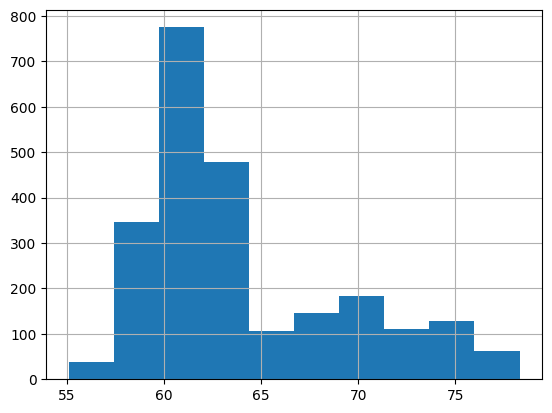

In [21]:
data['Performance_Score'].hist()

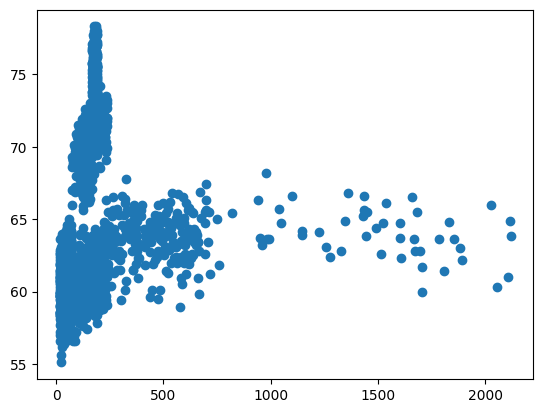

In [22]:
plt.scatter(data['Battery_Life_Hours'], data['Performance_Score'])

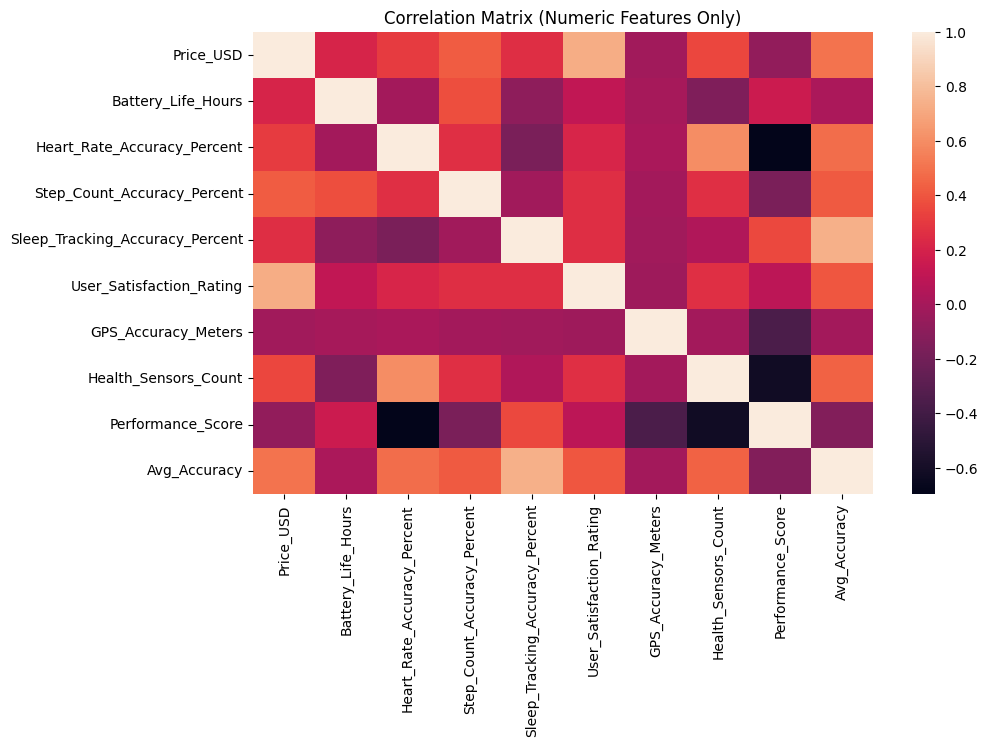

In [24]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr())
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

In [25]:
categorical_cols = ...
LabelEncoder()

LabelEncoder()

In [26]:
X = data.drop('Performance_Score', axis=1)
y = data['Performance_Score']

In [31]:
# Convert date column (if exists)
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
    data['Year'] = data['Date'].dt.year
    data['Month'] = data['Date'].dt.month
    data['Day'] = data['Date'].dt.day
    data.drop('Date', axis=1, inplace=True)
                                                                          #convert non numerical data into numerical
                                                                          
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col].astype(str))

# Define X and y
X = data.drop('Performance_Score', axis=1)
y = data['Performance_Score']

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [38]:
def evaluate(model):
    y_pred = model.predict(X_test)
    
    print("Model:", model.__class__.__name__)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("-" * 30)

In [39]:
lr = LinearRegression()
rf = RandomForestRegressor()
...

Ellipsis

In [42]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor(n_estimators=150, random_state=42)

In [44]:
# Check missing values
print("Missing values in X:", np.isnan(X_scaled).sum())
print("Missing values in y:", y.isnull().sum())

# Replace NaN with column mean
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_scaled = imputer.fit_transform(X_scaled)

Missing values in X: 4445
Missing values in y: 0


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Handle missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# 2. Scale data                                                
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 4. Check (important)
print("NaN in X_train:", np.isnan(X_train).sum())

NaN in X_train: 0


In [51]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [52]:
evaluate(lr)
evaluate(dt)
evaluate(rf)

Model: LinearRegression
R2 Score: 0.9016066517690913
RMSE: 1.514214888802758
MAE: 1.248684112618414
------------------------------
Model: DecisionTreeRegressor
R2 Score: 0.9844347114336978
RMSE: 0.6022589056823353
MAE: 0.46884210526315795
------------------------------
Model: RandomForestRegressor
R2 Score: 0.9954594858408584
RMSE: 0.32527984892544304
MAE: 0.2485894736842117
------------------------------


In [53]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='r2')
print(scores)

[0.99515959 0.99553979 0.99594539 0.99580985 0.99307249]


In [54]:
import numpy as np
print("Mean CV Score:", np.mean(scores))

Mean CV Score: 0.9951054198555884


In [55]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10, None]
}

In [56]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [100, 150]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

In [57]:
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 150}


In [58]:
evaluate(best_model)

Model: RandomForestRegressor
R2 Score: 0.9954594858408584
RMSE: 0.32527984892544304
MAE: 0.2485894736842117
------------------------------


In [59]:
importance = best_model.feature_importances_

In [66]:
# Save column names BEFORE preprocessing (run earlier once)
feature_names = data.drop('Performance_Score', axis=1).columns

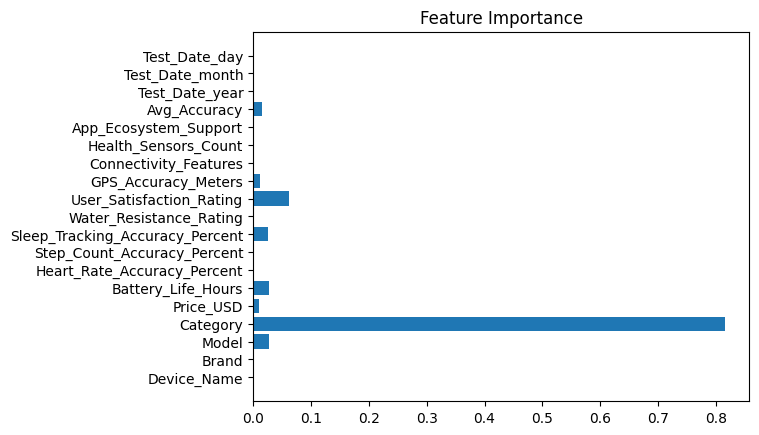

In [67]:
plt.figure()
plt.barh(range(len(importance)), importance)
plt.yticks(range(len(importance)), feature_names)
plt.title("Feature Importance")
plt.show()

In [68]:
y_pred = best_model.predict(X_test)

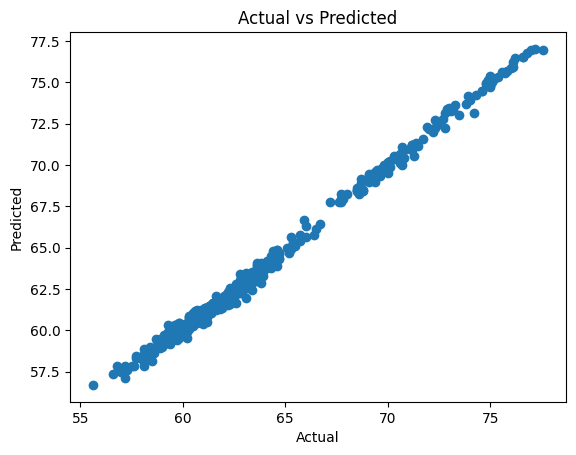

In [69]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [70]:
import joblib

joblib.dump(best_model, "wearable_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [71]:
model = joblib.load("wearable_model.pkl")
scaler = joblib.load("scaler.pkl")

In [ ]:
sample = X[0:1]
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)                   #this is the predicted Performance Score for one sample device
print("Prediction:", prediction)                               #he model predicts this device has a performance score of about 68.5”

Prediction: [68.526]


In [ ]:
print(data['Performance_Score'].min())                  #78.3 is highest perfomance
print(data['Performance_Score'].max())                  #55.1 is lowest perfomace
                                                        

55.1
78.3


# This device performs better than average but not at the top level.”